# Proyecto Integrador: Curso de Especialización en IA y Big Data
### Guillermo Díez Carro

## Fase 1: Comprensión del negocio

### Objetivo del proyecto

El objetivo de este proyecto es desarrollar un pipeline de datos híbrido capaz de integrar información energética, meteorológica y contextual para analizar y predecir la demanda eléctrica en España.

Para ello se utilizará una arquitectura medallón (Bronce, Plata y Oro) combinando servicios en la nube (AWS) y procesamiento local.

---

### Valor del proyecto

#### Impacto económico
- Optimización de costes energéticos.
- Mejora en la planificación del consumo y producción eléctrica.
- Mayor aprovechamiento de recursos renovables.

#### Impacto medioambiental
- Reducción indirecta de emisiones contaminantes.
- Disminución de la dependencia de combustibles fósiles.
- Uso más eficiente de energías renovables.

---

### Fuentes de datos

#### Datos energéticos
Uso de la API pública de ENTSO-E para obtener información histórica sobre demanda y generación eléctrica.

- www.entsoe.eu

#### Datos meteorológicos
Históricos climáticos de AEMET obtenidos desde DatosClima.

Variables principales:
- Temperatura
- Viento
- Precipitaciones

- datosclima.es

#### Datos contextuales
Se incorporarán datos de festivos y calendario laboral mediante:
- Librería holidays
- Ficheros CSV complementarios

---

### Variable objetivo

La variable principal será el consumo eléctrico nacional medido en MW para una fecha y hora determinadas.

Se trata de un problema de predicción numérica basado en series temporales.

---

### Riesgos y calidad de los datos

Posibles problemas:
- Valores nulos o incompletos.
- Diferencias de formato entre fuentes.
- Registros duplicados o faltantes.

Factores que afectan a la demanda:
- Festivos.
- Fines de semana.
- Estaciones del año.
- Condiciones meteorológicas.

---

### Preparación de los datos

#### Capa Bronce
- Almacenamiento de datos originales en AWS S3.
- Automatización mediante AWS Lambda.

#### Capa Plata
- Descarga de datos desde AWS usando `boto3`.
- Limpieza y transformación con Pandas.
- Conversión a formato Parquet.

#### Capa Oro
- Integración de todas las fuentes.
- Creación de variables derivadas:
  - `es_festivo`
  - `es_fin_semana`
  - `dia_semana`
  - `mes`

---

### Evaluación

#### Métricas técnicas
- RMSE
- MAPE (<5%)

#### Objetivos funcionales
- Pipeline estable y automatizado.
- Datos preparados para análisis y visualización.

---

### Despliegue

El proyecto finalizará con un dashboard interactivo conectado a la capa Gold para visualizar:
- Evolución de la demanda energética.
- Relación entre clima y consumo.
- Patrones temporales y estacionales.


## Fase 2: Comprensión de los datos

Realizaremos una exploración sobre los datos disponibles, posibles relaciones y transformaciones que puedan ser adecuadas y útiles más adelante.

In [ ]:
!pip install "numpy<2.0" --upgrade
!pip install boto3
!pip install pyarrow
!pip install vega_datasets
!pip install lxml
!pip install rarfile
!pip install xlrd
!pip install entsoe-py
!pip install holidays
!pip install awswrangler
!pip install beautifulsoup4
!pip install altair

In [ ]:
# =========================================================
# LIBRERÍAS Y CONFIGURACIÓN BASE DEL PROYECTO
# =========================================================

import os
import io
import json
import math
import shutil
import datetime

import boto3
import pandas as pd
import numpy as np
import awswrangler as wr

import requests
from urllib.parse import urljoin
from requests.exceptions import Timeout, RequestException

import rarfile
import subprocess
import holidays

import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt

from bs4 import BeautifulSoup


# =========================================================
# ENDPOINTS DE DATOS
# =========================================================

API_REE_URL = "https://apidatos.ree.es"
DATOS_CLIMA = "https://datosclima.es/Aemet2013/DescargaDatos.html"


# =========================================================
# CONFIGURACIÓN DE STORAGE
# =========================================================

BUCKET_BRONCE = "gdc-pi-bronce"
BUCKET_PLATA = "gdc-pi-plata"
BUCKET_ORO = "gdc-pi-oro"

DIR_TEMP = "./tempfiles"

rarfile.UNRAR_TOOL = "/opt/conda/bin/unrar"


# =========================================================
# CONEXIÓN AWS S3
# =========================================================

def connect_s3():
    """
    Inicializa cliente de S3.
    """
    try:
        s3 = boto3.client("s3")
        print("Conexión establecida con S3.")
        return s3

    except Exception as e:
        print("Error al conectar con S3.")
        print(e)
        return None


# =========================================================
# INGESTA A S3 (CSV EN MEMORIA)
# =========================================================

def upload_raw_data_to_s3(s3, bucket, filename, data):
    print("Subiendo dataset a S3 (modo memoria)...")

    buckets = [b["Name"] for b in s3.list_buckets().get("Buckets", [])]

    if bucket not in buckets:
        s3.create_bucket(Bucket=bucket)

    buffer = io.StringIO()
    data.to_csv(buffer, index=False)

    key = filename.replace("-", "/")
    key = os.path.splitext(key)[0] + ".csv"

    s3.put_object(
        Bucket=bucket,
        Key=key,
        Body=buffer.getvalue().encode("utf-8")
    )

    print(f"OK -> s3://{bucket}/{key}")


# =========================================================
# SUBIDA DE ARCHIVOS LOCALES
# =========================================================

def upload_from_disk_to_s3(s3, bucket, path, data):

    buckets = [b["Name"] for b in s3.list_buckets().get("Buckets", [])]

    if bucket not in buckets:
        s3.create_bucket(Bucket=bucket)

    s3.upload_file(data, bucket, path)

    print(f"Archivo subido -> s3://{bucket}/{path}")


# =========================================================
# EXPORTACIÓN PARQUET
# =========================================================

def upload_parquet_to_s3(s3, bucket, path, df):

    target = f"s3://{bucket}/{path}.parquet"
    print(f"Exportando parquet en {bucket}...")

    try:
        if df is not None and not df.empty:
            wr.s3.to_parquet(
                df=df,
                path=target,
                index=False
            )

        print(f"Parquet guardado -> {target}")

    except Exception as e:
        print(f"ERROR parquet: {e}")
        raise


# =========================================================
# DESCARGA DESDE S3
# =========================================================

def download_from_s3(s3, bucket, object_path):

    local_path = os.path.join("s3_downloads", object_path)

    try:
        print(f"Descargando s3://{bucket}/{object_path}")

        s3.download_file(bucket, object_path, local_path)

        print(f"Guardado en {local_path}")

    except Exception as e:
        print(f"ERROR descarga: {e}")

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Fase 3: Preparación de los daros

### Capa bronce
API ENTSO-E

In [ ]:
# =========================================================
# IMPORTACIÓN Y CONFIGURACIÓN ENTSO-E
# =========================================================

from entsoe import EntsoePandasClient
import pandas as pd


# =========================================================
# CONSTANTES DEL PROYECTO
# =========================================================

ENTSOE_KEY = ""
SPAIN_CODE = "ES"
ENTSOE_KEY_FILE = "entsoe-key.txt"


# =========================================================
# CARGA DE API KEY
# =========================================================

try:
    with open(ENTSOE_KEY_FILE, "r") as f:
        ENTSOE_KEY = f.read().strip()

    if not ENTSOE_KEY:
        raise ValueError("API key vacía en el archivo.")

except FileNotFoundError:
    raise FileNotFoundError(
        "No se encontró el archivo entsoe-key.txt. "
        "Crea el fichero con tu API key."
    )


# =========================================================
# CONEXIÓN A ENTSO-E
# =========================================================

def connect_entsoe():
    """
    Inicializa cliente ENTSO-E con la API key cargada.
    """
    return EntsoePandasClient(ENTSOE_KEY)


# =========================================================
# EXTRACCIÓN DE DATOS
# =========================================================

def get_entsoe_data(entsoe_client, year):
    """
    Descarga generación eléctrica para un año concreto.
    """

    print(f"Extrayendo datos ENTSO-E ({year})...")

    start = pd.Timestamp(f"{year}-01-01", tz="Europe/Madrid")
    end = pd.Timestamp(f"{year}-12-31 23:59", tz="Europe/Madrid")

    try:
        data = entsoe_client.query_generation(
            SPAIN_CODE,
            start=start,
            end=end
        )

        # Normalización de estructura (MultiIndex handling)
        if isinstance(data.columns, pd.MultiIndex):
            data = data.xs(
                "Actual Aggregated",
                axis=1,
                level=1
            )

        # Conversión del índice temporal a columna
        data = (
            data.reset_index()
                .rename(columns={"index": "Datetime"})
        )

        print(f"Datos ENTSO-E {year} descargados correctamente.")

        return data

    except Exception as e:
        print(f"ERROR en ENTSO-E ({year}): {e}")
        return pd.DataFrame()

In [ ]:
# =========================================================
# PIPELINE DE INGESTA - CAPA BRONCE (ENTSO-E)
# =========================================================

# Conexiones iniciales
s3 = connect_s3()
entsoe_client = connect_entsoe()

# Rango de años (2027 excluido)
YEARS_RANGE = range(2020, 2027)

print("Iniciando pipeline de ingesta ENTSO-E (capa bronce)...")

for i in YEARS_RANGE:

    print(f"\n--- Procesando año {i} ---")

    # Extracción de datos
    raw_entsoe = get_entsoe_data(entsoe_client, i)

    # Ruta en S3
    s3_path = f"entsoe/year={i}/raw_{i}"

    # Subida a S3 (capa bronce)
    upload_raw_data_to_s3(
        s3,
        BUCKET_BRONCE,
        s3_path,
        raw_entsoe
    )

print("\nPipeline bronce finalizado correctamente.")

Conexión establecida.
Descargando los datos brutos de generación de energía de ENTSO-E del año 2020
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3:/gdc-pi-bronce/entsoe/year=2020/raw_2020.csv
Descargando los datos brutos de generación de energía de ENTSO-E del año 2021
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3:/gdc-pi-bronce/entsoe/year=2021/raw_2021.csv
Descargando los datos brutos de generación de energía de ENTSO-E del año 2022
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3:/gdc-pi-bronce/entsoe/year=2022/raw_2022.csv
Descargando los datos brutos de generación de energía de ENTSO-E del año 2023
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3:/gdc-pi-bronce/entsoe/year=2023/raw_2023.csv
Descargando los datos brutos de generación de energía de ENTSO-E del año 2024
Subiendo datos a S3 desde memoria
Datos subidos con éxito a s3:/gdc-pi-bronce/entsoe/year=2024/raw_2024.csv
Descargando los datos brutos de generación de en

### Procesamiento de datos ENTSO-E en capa bronce

El pipeline anterior se encarga de extraer información desde la API de ENTSO-E y almacenarla en la capa bronce del data lake en Amazon S3.

Los datos obtenidos a través de esta API vienen en formato horario y con nomenclatura en inglés. Para su tratamiento, se utiliza una función AWS Lambda que se activa automáticamente cuando se detectan nuevos ficheros con prefijo `entsoe/` en el bucket de entrada.

---

#### Transformaciones realizadas en AWS Lambda

La función Lambda realiza las siguientes operaciones:

- Traducción de nombres de columnas del inglés al español.
- Conversión de datos horarios a agregación diaria.
- Transformación del dataset a formato optimizado Parquet.
- Almacenamiento en la capa plata con estructura particionada por año.

El resultado se guarda en la ruta:

```
energia_consolidada/year=YYYY/energia_YYYY.parquet
```

---

#### Función Lambda de procesamiento

```python
import json
import urllib.parse
import boto3
import pandas as pd
import awswrangler as wr
import io


# =========================================================
# MAPEO DE COLUMNAS (INGLÉS → ESPAÑOL)
# =========================================================

TRANSLATION_ENTSOE = {
    "datetime": "fecha_hora",
    "Biomass": "biomasa_mwh",
    "Fossil Brown coal/Lignite": "carbon_marron_lignito_mwh",
    "Fossil Coal-derived gas": "gas_derivado_carbon_mwh",
    "Fossil Gas": "gas_natural_mwh",
    "Fossil Hard coal": "hulla_antracita_mwh",
    "Fossil Oil": "petroleo_mwh",
    "Fossil Oil shale": "esquisto_bituminoso_mwh",
    "Fossil Peat": "turba_mwh",
    "Geothermal": "geotermica_mwh",
    "Hydro Run-of-river and poundage": "hidraulica_fluyente_mwh",
    "Hydro Water Reservoir": "hidraulica_embalse_mwh",
    "Marine": "maritima_mwh",
    "Nuclear": "nuclear_mwh",
    "Other": "otras_tecnologias_mwh",
    "Other renewable": "otras_renovables_mwh",
    "Solar": "solar_fotovoltaica_mwh",
    "Waste": "residuos_mwh",
    "Wind Offshore": "eolica_marina_mwh",
    "Wind Onshore": "eolica_terrestre_mwh"
}

BUCKET_PLATA = "gdc-pi-plata"


# =========================================================
# LAMBDA HANDLER
# =========================================================

def lambda_handler(event, context):

    bucket_bronce = event["Records"][0]["s3"]["bucket"]["name"]

    key_bronce = urllib.parse.unquote_plus(
        event["Records"][0]["s3"]["object"]["key"],
        encoding="utf-8"
    )

    # Ejemplo de ruta: entsoe/year=2020/raw_data_2020.csv
    year = key_bronce.split("=")[1].split("/")[0]

    try:
        # Lectura desde S3 (capa bronce)
        df_raw = wr.s3.read_csv(
            path=f"s3://{bucket_bronce}/{key_bronce}"
        )

        # Conversión temporal
        df_raw["Datetime"] = pd.to_datetime(df_raw["Datetime"], utc=True)
        df_raw = df_raw.set_index("Datetime")

        # Filtrado y renombrado de columnas relevantes
        cols = [
            c for c in TRANSLATION_ENTSOE.keys()
            if c in df_raw.columns
        ]

        df_final = df_raw[cols].rename(columns=TRANSLATION_ENTSOE)

        # Agregación diaria
        df_daily = (
            df_final
            .resample("D")
            .sum()
            .reset_index()
        )

        df_daily["fecha"] = df_daily["Datetime"].dt.date
        df_daily.drop(columns=["Datetime"], inplace=True)

        # Escritura en capa plata (Parquet)
        output_path = (
            f"s3://{BUCKET_PLATA}/"
            f"energia_consolidada/year={year}/energia_{year}.parquet"
        )

        wr.s3.to_parquet(
            df=df_daily,
            path=output_path,
            index=False
        )

    except Exception as e:
        print(f"ERROR: {e}")
```

### Obtención de datos climáticos (AEMET)

Fuente: https://datosclima.es/Aemet2013/DescargaDatos.html

Los datos meteorológicos utilizados en este proyecto proceden de la AEMET y se encuentran disponibles a través de la plataforma datosclima.es, que recopila información histórica desde mayo de 2013.

En este repositorio se pueden consultar múltiples variables climáticas organizadas por año y mes, en formato de tablas descargables.

---

#### Automatización mediante Web Scraping

Dado que la descarga manual de los ficheros mensuales resultaría un proceso poco eficiente y propenso a errores, se ha implementado un proceso de **web scraping** para automatizar la obtención de los datos.

Este proceso permite:

- Detectar automáticamente los enlaces de descarga disponibles en la web.
- Iterar sobre los distintos años y meses.
- Descargar los archivos de forma sistemática.
- Almacenar los datos directamente en Amazon S3 para su posterior tratamiento.

---

#### Almacenamiento en AWS

Los datos descargados mediante scraping se almacenan en la capa bronce del Data Lake en Amazon S3, siguiendo la arquitectura del proyecto, para su posterior procesamiento en fases de limpieza y transformación.

Este enfoque permite mantener un flujo automatizado de ingesta de datos climáticos, reduciendo la intervención manual y asegurando la escalabilidad del sistema.

In [ ]:
# =========================================================
# DESCARGA Y PROCESAMIENTO DE DATOS CLIMÁTICOS (AEMET)
# =========================================================

import os
import shutil
import subprocess
import requests
import pandas as pd

from urllib.parse import urljoin
from bs4 import BeautifulSoup
from requests.exceptions import Timeout, RequestException


# =========================================================
# DESCARGA Y DESCOMPRESIÓN DE ARCHIVOS RAR
# =========================================================

def unpack_rar(url, filename, dir=DIR_TEMP):

    filename = filename.split("/")[-1]  # limpieza de ruta

    # Reinicio del directorio temporal
    if os.path.exists(dir):
        shutil.rmtree(dir)

    os.makedirs(dir, exist_ok=True)

    rar_path = os.path.join(dir, filename)

    try:
        print(f"Descargando: {url}")

        headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
            "Referer": "https://datosclima.es/Aemet2013/DescargaDatos.html"
        }

        response = requests.get(
            url,
            stream=True,
            timeout=(3, 10),
            headers=headers
        )

        response.raise_for_status()

        # Guardado del archivo comprimido
        with open(rar_path, "wb") as file:
            for chunk in response.iter_content(chunk_size=8192):
                file.write(chunk)

        # Validación básica de descarga
        file_size = os.path.getsize(rar_path)

        if file_size < 1000:
            print("ERROR: El servidor no ha enviado un .rar válido")

            with open(rar_path, "r", encoding="utf-8", errors="ignore") as f:
                print(f.read())

            return False

        print("Descomprimiendo...")

        output_dir = os.path.join(dir, "")

        command = ["unrar", "x", "-y", rar_path, output_dir]

        subprocess.run(command, capture_output=True, text=True)

        extracted_files = len(os.listdir(dir)) - 1  # excluye .rar

        print(f"Número de elementos descomprimidos: {extracted_files}")

        return True

    except Timeout:
        print("ERROR: El servidor tardó demasiado en responder.")
        return False

    except Exception as e:
        print(f"ERROR: {e}")
        return False


# =========================================================
# CONVERSIÓN DE ARCHIVOS EXCEL A DATAFRAME
# =========================================================

def convert_files_to_df():

    dfs = []
    tempfiles_path = "tempfiles"

    print("Convirtiendo archivos Excel a DataFrames...")

    if not os.path.exists(tempfiles_path):
        return dfs

    for file in os.listdir(tempfiles_path):

        if file.endswith(".xls"):

            path = os.path.join(tempfiles_path, file)

            try:
                df = pd.read_excel(
                    path,
                    engine="xlrd",
                    skiprows=4
                )

                df["archivo_origen"] = file
                dfs.append((file, df))

            except Exception:
                # Se ignoran ficheros corruptos o no válidos
                continue

    return dfs


# =========================================================
# PIPELINE PRINCIPAL AEMET (SCRAPING + INGESTA)
# =========================================================

def get_aemet2013_data():

    s3 = connect_s3()

    try:
        response = requests.get(DATOS_CLIMA, timeout=(3, 10))
        response.raise_for_status()
        response.encoding = "utf-8"

        soup = BeautifulSoup(response.text, "html.parser")

        links = soup.find_all("a")

        for link in links:

            path = link.get("href")

            if "../capturadatos/" in str(path):

                full_url = urljoin(
                    "https://datosclima.es",
                    path
                )

                if unpack_rar(full_url, path):

                    dfs = convert_files_to_df()

                    for filename, df in dfs:
                        upload_raw_data_to_s3(
                            s3,
                            BUCKET_BRONCE,
                            filename,
                            df
                        )

    except Timeout:
        print("ERROR: El servidor tardó demasiado en responder.")

    except RequestException as e:
        print(f"ERROR: {e}")

In [ ]:
get_aemet2013_data()

### Consideraciones previas y entorno de ejecución

Se ha limpiado la salida de la celda anterior debido a su tamaño, ya que el proceso de scraping genera una gran cantidad de logs y archivos intermedios.

---

#### Dependencias del sistema

Para el correcto funcionamiento de la librería `rarfile` es necesario disponer de una herramienta de descompresión compatible como **WinRAR** o **unrar** instalada en el sistema.

En este proyecto, el entorno de ejecución se basa en un contenedor Docker utilizando la imagen:

```
jupyter/datascience-notebook
```

Debido a las restricciones del entorno (falta de permisos para usar `apt-get`), la instalación del descompresor se ha realizado mediante Conda:

```
conda install -c conda-forge unrar -y
```

---

### Estructura de los datos climáticos

Los datos disponibles en la plataforma se organizan en forma de tablas accesibles desde la web.

Cada tabla corresponde a un año completo, subdividido por meses. A su vez, cada mes contiene un enlace de descarga en formato `.rar`.

Al descomprimir estos archivos, se obtienen múltiples ficheros `.xls`, generalmente uno por cada día del mes (aproximadamente entre 30 y 31 archivos).

---

### Almacenamiento en AWS S3

Una vez procesados, los datos se almacenan en Amazon S3 siguiendo una estructura jerárquica organizada por:

```
año / mes / día
```

o de forma equivalente, manteniendo una organización que facilita su posterior explotación analítica.

Este esquema permite mantener un Data Lake estructurado dentro de la capa bronce, facilitando la trazabilidad y el procesamiento posterior en las capas plata y oro.

### Librería "Holidays"

Esta librería permite obtener los días festivos de diferentes zonas del mundo, incluidas las Comunidades Autónomas de España.

Este proceso se llevará a cabo con una función lambda, que se disparará al subir los datos de la AEMET. Su función será añadir en el csv si el día era festivo o no y guardará el objeto en la capa plata.

Además, como las funciones lambda de AWS se cobran por invocación y tiempo de ejecución, se filtrarán los datos para que sólo se aplique a los datos desde 2020 hasta 2026. Se crea una notificación por año (Aemet2020, Aemet2021...)

Función Lambda:

```python
import json
import urllib.parse
import boto3
import pandas as pd
import holidays
from datetime import datetime
import io

s3_client = boto3.client("s3") # lo creo fuera del handler para poder reutilizar la conexión

PROVINCIAS_CCAA = {
    # Andalucía (AN)
    "ALMERÍA": "AN", "CÁDIZ": "AN", "CÓRDOBA": "AN", "GRANADA": "AN", 
    "HUELVA": "AN", "JAÉN": "AN", "MÁLAGA": "AN", "SEVILLA": "AN",
    # Aragón (AR)
    "HUESCA": "AR", "TERUEL": "AR", "ZARAGOZA": "AR",
    # Principado de Asturias (AS)
    "ASTURIAS": "AS",
    # Canarias (CN)
    "LAS PALMAS": "CN", "SANTA CRUZ DE TENERIFE": "CN",
    # Cantabria (CB)
    "CANTABRIA": "CB",
    # Castilla y León (CL)
    "ÁVILA": "CL", "BURGOS": "CL", "LEÓN": "CL", "PALENCIA": "CL", 
    "SALAMANCA": "CL", "SEGOVIA": "CL", "SORIA": "CL", "VALLADOLID": "CL", "ZAMORA": "CL",
    # Castilla-La Mancha (CM)
    "ALBACETE": "CM", "CIUDAD REAL": "CM", "CUENCA": "CM", "GUADALAJARA": "CM", "TOLEDO": "CM",
    # Cataluña (CT)
    "BARCELONA": "CT", "GIRONA": "CT", "GERONA": "CT", "LLEIDA": "CT", "LÉRIDA": "CT", "TARRAGONA": "CT",
    # Extremadura (EX)
    "BADAJOZ": "EX", "CÁCERES": "EX",
    # Galicia (GA)
    "A CORUÑA": "GA", "LA CORUÑA": "GA", "LUGO": "GA", "OURENSE": "GA", "ORENSE": "GA", "PONTEVEDRA": "GA",
    # Illes Balears (IB)
    "BALEARES": "IB", "ILLES BALEARS": "IB", "ISLAS BALEARES": "IB",
    # La Rioja (RI)
    "LA RIOJA": "RI",
    # Comunidad de Madrid (MD)
    "MADRID": "MD",
    # Región de Murcia (MC)
    "MURCIA": "MC",
    # Comunidad Foral de Navarra (NC)
    "NAVARRA": "NC",
    # País Vasco (PV)
    "ÁLAVA": "PV", "ARABA": "PV", "GUIPÚZCOA": "PV", "GIPUZKOA": "PV", "VIZCAYA": "PV", "BIZKAIA": "PV",
    # Comunidad Valenciana (VC)
    "ALICANTE": "VC", "ALACANT": "VC", "CASTELLÓN": "VC", "CASTELLÓ": "VC", "VALENCIA": "VC", "VALÈNCIA": "VC",
    # Ciudades Autónomas
    "CEUTA": "CE",
    "MELILLA": "ML"
}

BUCKET_DESTINO = "gdc-pi-meteo-y-vacaciones"

def lambda_handler(event, context):
    bucket = event["Records"][0]["s3"]["bucket"]["name"]
    key = urllib.parse.unquote_plus(event["Records"][0]["s3"]["object"]["key"], encoding="utf-8")

    print(f"Procesando: {key} de {bucket}")

    try:
        response = s3_client.get_object(Bucket = bucket, Key = key)
        path_splitted = key.split("/")

        year = int(path_splitted[0].replace("Aemet", ""))
        month = int(path_splitted[1])
        day = int(path_splitted[2].replace(".csv", ""))

        if year < 2020:
            print("ERROR: El fichero era anterior a 2020.")
            return
        
        df = pd.read_csv(io.BytesIO(response["Body"].read()))

        # Si no pongo la fecha en formato de pandas da errores
        current_date = pd.to_datetime(f"{year}-{month}-{day}")
        df["fecha"] = current_date

        # Separa la provincia en 2 partes (Alacant/Alicante) para quedarse con la última
        df["Provincia_Limpia"] = df["Provincia"].str.split("/").str[-1]
        df["ccaa_codigo"] = df["Provincia_Limpia"].str.strip().str.upper().map(PROVINCIAS_CCAA)
        
        df["es_festivo"] = 0

        # Es posible que deje algunas sin mapear sin darme cuenta, así que me dejo de problemas con esto
        ccaa_dataset = df["ccaa_codigo"].dropna().unique()

        for ccaa in ccaa_dataset:
            # Obtiene festivos para la comunidad autónoma específica
            country_holidays = holidays.ES(subdiv = ccaa, years = year)

            if current_date in country_holidays:
                df.loc[df["ccaa_codigo"] == ccaa, "es_festivo"] = 1
        
        s3_client.put_object(
            Bucket = BUCKET_DESTINO,
            Key = f"{key}",
            Body = df.to_csv(index = False),
            ContentType = "text/csv"
        )
        print(f"Fichero procesado y almacenado en: {BUCKET_DESTINO}/{key}")
    except Exception as e:
        print(e)
        raise e

```

### Capa Plata

---

#### Compactación de datos

Tal y como se ha descrito en la fase de ingesta, los datos almacenados en la capa bronce se encuentran organizados en múltiples ficheros `.csv` distribuidos por día.

La estructura de almacenamiento sigue un esquema jerárquico en el que los datos se organizan por año, y dentro de cada año se subdividen en carpetas mensuales. A su vez, cada mes contiene múltiples ficheros diarios en formato `.csv`, correspondientes a cada uno de los días del periodo.

De este modo, un ejemplo de organización sería el correspondiente al año 2020, donde se agrupan las carpetas mensuales (01, 02, 03, etc.), y dentro de cada una se encuentran los archivos diarios (01.csv, 02.csv, 03.csv, y así sucesivamente). Esta misma estructura se replica para el resto de meses y años disponibles.

---

Esta organización granular, aunque útil para la ingesta inicial, dificulta el procesamiento analítico posterior debido al elevado número de ficheros y su baja agregación.

Por este motivo, se ha definido un proceso de **compactación de datos por año**, con el objetivo de facilitar el tratamiento en etapas posteriores del pipeline.

---

#### Automatización del proceso

Inicialmente, se planteó la ejecución periódica de este proceso mediante una regla programada (Cron) gestionada a través de AWS EventBridge.

Sin embargo, para simplificar el desarrollo y evitar dependencias temporales, se ha optado por implementar una **AWS Lambda invocable manualmente**, manteniendo la posibilidad de automatización futura sin cambios en el código.

---

#### Función Lambda de compactación

```python
import json
import pandas as pd
import awswrangler as wr


# =========================================================
# CONFIGURACIÓN DE BUCKETS
# =========================================================

BUCKET_METEO_VACACIONES = "gdc-pi-meteo-y-vacaciones"
BUCKET_PLATA = "gdc-pi-plata"


# =========================================================
# LAMBDA HANDLER
# =========================================================

def lambda_handler(event, context):

    year = event.get("year", None)

    if not year:
        raise ValueError("No se ha especificado el año.")

    print(f"Iniciando proceso de compactación para el año: {year}")

    try:
        # Lectura de datos brutos en S3 (capa bronce)
        source_path = f"s3://{BUCKET_METEO_VACACIONES}/Aemet{year}/"
        df_anual = wr.s3.read_csv(path=source_path)

        # Validación básica
        if df_anual.empty:
            print("El dataset anual está vacío.")
            return

        # Ruta de salida en capa plata
        output_path = (
            f"s3://{BUCKET_PLATA}/"
            f"aemet_consolidada/year={year}/aemet_historico_{year}.parquet"
        )

        # Escritura en formato optimizado
        wr.s3.to_parquet(
            df=df_anual,
            path=output_path,
            index=False
        )

        print(f"Compactación completada correctamente para el año {year}")

    except Exception as e:
        print(f"ERROR durante la compactación: {e}")
        raise
```##

In [ ]:
import boto3
import json

# =========================================================
# CLIENTE AWS LAMBDA
# =========================================================

client = boto3.client("lambda", region_name="us-east-1")


# =========================================================
# INVOCACIÓN DEL PROCESO DE COMPACTACIÓN
# =========================================================

try:
    print("Iniciando invocación de Lambda para compactación...")

    for year in range(2020, 2027):

        payload = {
            "year": year
        }

        response = client.invoke(
            FunctionName="compact-data",
            InvocationType="RequestResponse",
            Payload=json.dumps(payload).encode("utf-8")
        )

    print("Ejecución de Lambda completada correctamente.")

except Exception as e:
    print(f"ERROR: {e}")

### Unificación y compactación completa de datos

Una vez que tenemos los datos de días con la meteorología y los datos de generación necesitamos compactarlos en un mismo dataset para poder operar de manera eficiente con ello. Aunque las transformaciones en los datos de generación las he considerado como de capa plata, esta unificación de todos los datos también la consideraré como tal, pues aún no se han realizado procesos de limpieza de datos como tal, simplemente se ha realizado un enriquecimiento.

Como los datos que he enriquecido son los de los años 2020 en adelante, estos serán los que utilice en este punto.

In [ ]:
# =========================================================
# UNIFICACIÓN DE DATASETS (ENERGÍA + METEO)
# =========================================================

BUCKET_PLATA = "gdc-pi-plata"

dfs_energy = []
dfs_meteo_holidays = []

# =========================================================
# CARGA DE DATOS DESDE CAPA PLATA
# =========================================================

for year in range(2020, 2027):

    energy_path = f"s3://{BUCKET_PLATA}/energia_consolidada/year={year}"
    meteo_path = f"s3://{BUCKET_PLATA}/aemet_consolidada/year={year}"

    dfs_energy.append(
        wr.s3.read_parquet(path=energy_path)
    )

    dfs_meteo_holidays.append(
        wr.s3.read_parquet(path=meteo_path)
    )


# =========================================================
# CONCATENACIÓN DE DATASETS
# =========================================================

df_energy_full = pd.concat(dfs_energy)
df_aemet_full = pd.concat(dfs_meteo_holidays)


# =========================================================
# NORMALIZACIÓN DE FECHAS
# =========================================================

df_energy_full["fecha"] = (
    pd.to_datetime(df_energy_full["fecha"], utc=True)
    .dt.tz_localize(None)
    .dt.normalize()
)

df_aemet_full["fecha"] = (
    pd.to_datetime(df_aemet_full["fecha"], utc=True)
    .dt.tz_localize(None)
    .dt.normalize()
)

In [ ]:
# =========================================================
# UNIÓN FINAL DE DATASETS (MERGE POR FECHA)
# =========================================================

df_full = pd.merge(
    df_aemet_full,
    df_energy_full,
    on="fecha",
    how="inner"
)

# Visualización rápida del dataset resultante
df_full.head()

,Estación,Provincia,Temperatura_máxima__ºC_,Temperatura_mínima__ºC_,Temperatura_media__ºC_,Racha__km/h_,Velocidad_máxima__km/h_,Precipitación_00-24h__mm_,Precipitación_00-06h__mm_,Precipitación_06-12h__mm_,...,hidraulica_fluyente_mwh,hidraulica_embalse_mwh,maritima_mwh,nuclear_mwh,otras_tecnologias_mwh,otras_renovables_mwh,solar_fotovoltaica_mwh,residuos_mwh,eolica_marina_mwh,eolica_terrestre_mwh
0,Estaca de Bares,A Coruña,20.3 (13:50),14.9 (01:20),17.6,46 (03:10),40 (03:10),0.0,0.0,0.0,...,32022.0,74460.0,0.0,95104.0,1239.0,2465.0,67691.0,5141.0,0.0,46137.0
1,Ferrol,A Coruña,24.4 (14:40),15.6 (04:10),20.0,32 (17:00),23 (16:20),0.0,0.0,0.0,...,32022.0,74460.0,0.0,95104.0,1239.0,2465.0,67691.0,5141.0,0.0,46137.0
2,As Pontes,A Coruña,29.1 (15:30),13.8 (07:20),21.5,<NA>,<NA>,0.0,0.0,0.0,...,32022.0,74460.0,0.0,95104.0,1239.0,2465.0,67691.0,5141.0,0.0,46137.0
3,A Coruña,A Coruña,22.8 (12:50),15.8 (04:10),19.3,39 (02:00),22 (02:00),0.0,0.0,0.0,...,32022.0,74460.0,0.0,95104.0,1239.0,2465.0,67691.0,5141.0,0.0,46137.0
4,A Coruña Aeropuerto,A Coruña,22.1 (12:30),15.2 (06:40),18.7,37 (02:20),25 (16:50),0.0,0.0,0.0,...,32022.0,74460.0,0.0,95104.0,1239.0,2465.0,67691.0,5141.0,0.0,46137.0


In [ ]:
# =========================================================
# AJUSTE DE FORMATO DE FECHA Y COPIA DE SEGURIDAD
# =========================================================

df_full["fecha"] = pd.to_datetime(df_full["fecha"]).dt.date

# Copia del dataset para posibles transformaciones posteriores
df_full_copy = df_full.copy()

### Limpieza de datos

A partir de la inspección inicial del dataset, tanto mediante la función `head()` como a través de `describe()`, se observa la presencia de varias columnas que requieren tratamiento previo antes de su uso en el análisis.

Estas transformaciones son necesarias para garantizar la calidad de los datos y asegurar su consistencia en las fases posteriores del pipeline.

In [ ]:
# =========================================================
# ANÁLISIS DESCRIPTIVO DEL DATASET
# =========================================================

df_full.describe()

,Temperatura_media__ºC_,Precipitación_00-24h__mm_,Precipitación_00-06h__mm_,Precipitación_06-12h__mm_,Precipitación_12-18h__mm_,Precipitación_18-24h__mm_,fecha,es_festivo,biomasa_mwh,carbon_marron_lignito_mwh,...,hidraulica_fluyente_mwh,hidraulica_embalse_mwh,maritima_mwh,nuclear_mwh,otras_tecnologias_mwh,otras_renovables_mwh,solar_fotovoltaica_mwh,residuos_mwh,eolica_marina_mwh,eolica_terrestre_mwh
count,497686.000000,486948.000000,492093.000000,490623.000000,491575.000000,492751.000000,524881,524881.0,524881.000000,524881.0,...,524881.000000,524881.000000,524881.0,524881.00000,524881.000000,524881.000000,524881.000000,524881.000000,524881.0,5.248810e+05
mean,9.767342,3.368206,0.776317,0.892675,0.903023,0.798447,2026-02-13 22:23:59.846365,0.026566,36082.161023,0.0,...,120027.486017,357751.073017,0.0,579690.60123,470.337010,6118.421722,414250.807303,14355.257965,0.0,8.184246e+05
min,-14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2025-12-31 00:00:00,0.0,1612.000000,0.0,...,4272.000000,9400.000000,0.0,28464.00000,0.000000,272.000000,144.000000,848.000000,0.0,8.520000e+03
25%,6.900000,0.000000,0.000000,0.000000,0.000000,0.000000,2026-01-22 00:00:00,0.0,31704.000000,0.0,...,105724.000000,268708.000000,0.0,538156.00000,356.000000,5796.000000,254412.000000,11904.000000,0.0,4.502160e+05
50%,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2026-02-14 00:00:00,0.0,38344.000000,0.0,...,126784.000000,362352.000000,0.0,587716.00000,500.000000,6136.000000,402752.000000,14768.000000,0.0,8.582400e+05
75%,12.900000,2.600000,0.000000,0.100000,0.200000,0.200000,2026-03-09 00:00:00,0.0,41004.000000,0.0,...,138688.000000,473140.000000,0.0,682016.00000,664.000000,6616.000000,570328.000000,16700.000000,0.0,1.117800e+06
max,26.500000,581.500000,151.700000,133.300000,151.100000,145.400000,2026-03-31 00:00:00,1.0,46760.000000,0.0,...,156428.000000,577304.000000,0.0,683416.00000,972.000000,7176.000000,847064.000000,20348.000000,0.0,1.716292e+06
std,4.602619,8.915143,2.949548,3.249500,2.943985,2.775037,NaN,0.160811,7773.234896,0.0,...,25132.580695,127566.146233,0.0,102974.47590,274.012818,791.285618,199913.644440,3208.506305,0.0,4.088148e+05


#### Problemas detectados en los datos

A partir del análisis exploratorio realizado sobre el `describe()` del dataset, se identifican varios problemas relevantes que deben ser tratados antes de continuar con la fase de modelado.

Por un lado, se observan valores extremos en variables como la precipitación. Por ejemplo, mientras la media se sitúa en torno a `3.368`, se registran valores máximos de hasta `581.5`, lo que sugiere la presencia de outliers o eventos climáticos puntuales muy intensos. Además, la información relacionada con la precipitación presenta cierta redundancia, ya que existen varias columnas que miden acumulados en distintos intervalos temporales (incluyendo divisiones cada 4 horas).

Por otro lado, se detectan columnas relacionadas con la generación energética que no contienen valores. Aunque esto no representa un error en sí mismo (ya que algunas tecnologías no se utilizan en el mix energético español), sí introduce ineficiencias tanto en el almacenamiento como en el procesamiento de los datos, al añadir variables que no aportan información útil al modelo.

También se identifican problemas de formato en ciertas variables meteorológicas. En particular:
- Las temperaturas máxima y mínima incluyen información adicional en formato texto (por ejemplo, `10.5 (15:00)`), donde se mezcla el valor numérico con la hora de medición.
- Las rachas de viento presentan un formato similar, como `50 (1:00)`, donde también se combina magnitud y timestamp en la misma celda.

Finalmente, la matriz de correlación evidencia la existencia de columnas con ausencia total de valores, especialmente en aquellas tecnologías de generación no utilizadas en España. Estas variables serán eliminadas en fases posteriores, al considerarse redundantes y no aportar valor al análisis.

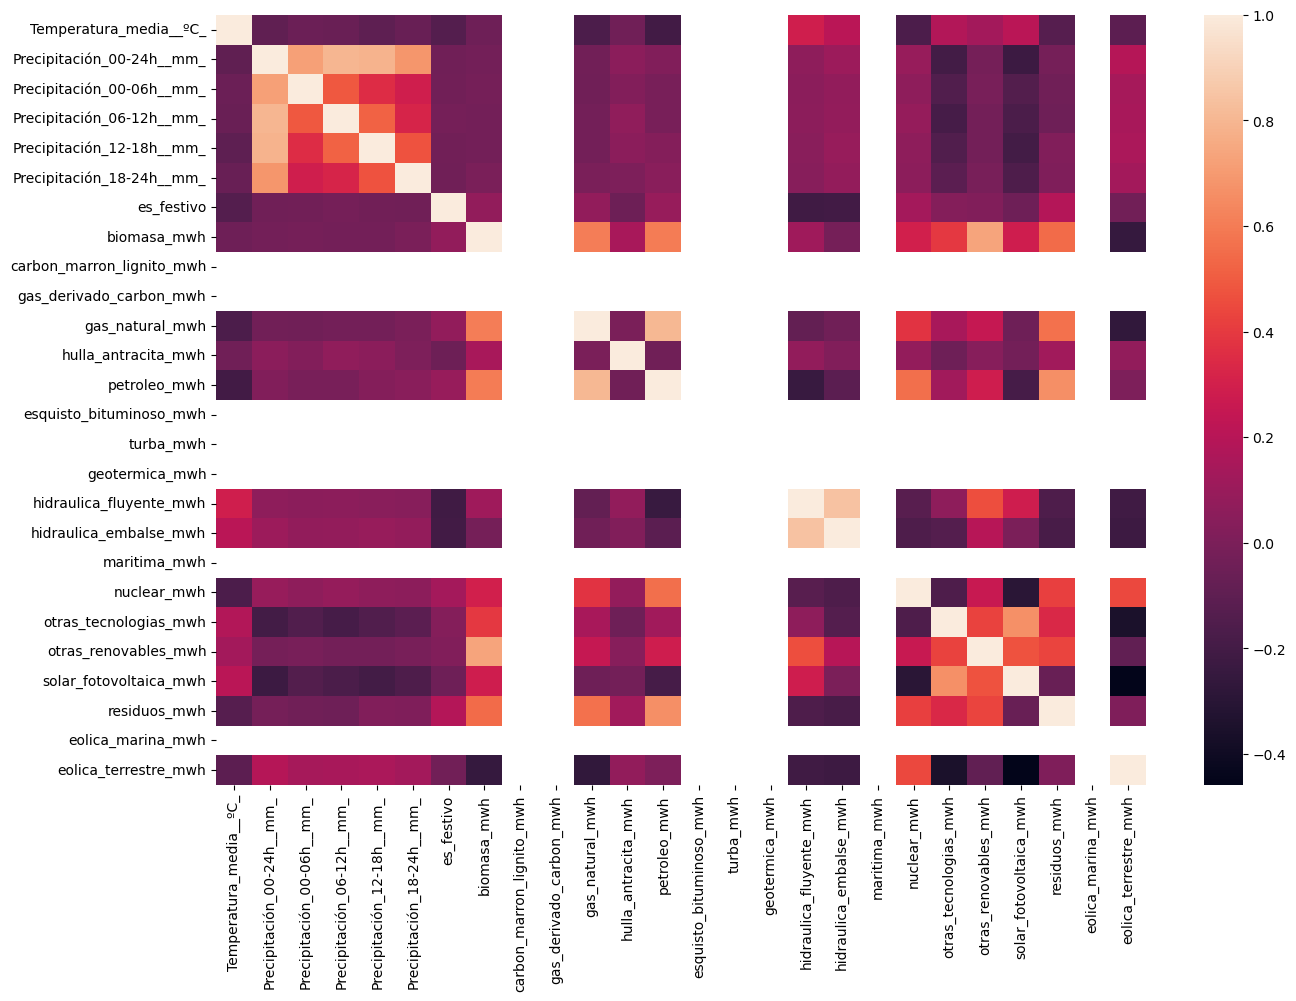

In [ ]:
# =========================================================
# MATRIZ DE CORRELACIÓN
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df_full.corr(numeric_only=True)

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix)

plt.show()

### Eliminación de variables redundantes o poco útiles

En esta fase se procede a eliminar aquellas columnas que no aportan información relevante para el análisis, presentan alta redundancia (multicolinealidad) o contienen valores completamente nulos.

El objetivo es simplificar la estructura del dataset, reducir su dimensionalidad y mejorar la eficiencia en las fases posteriores de modelado y análisis.

In [ ]:
def clean_value_hour_format(value):
    if isinstance(value, str):
        value, _ = splitted_value = value.split(" ")
    return float(value)

In [ ]:
# =========================================================
# LIMPIEZA Y NORMALIZACIÓN DE VARIABLES DE VIENTO
# =========================================================

# Sustitución de valores nulos
df_full_copy["Racha__km/h_"] = (
    df_full_copy["Racha__km/h_"]
    .fillna(0)
)

df_full_copy["Velocidad_máxima__km/h_"] = (
    df_full_copy["Velocidad_máxima__km/h_"]
    .fillna(0)
)

# Conversión de formatos tipo: "10.5 (10:30)"
df_full_copy["Racha__km/h_"] = (
    df_full_copy["Racha__km/h_"]
    .apply(clean_value_hour_format)
)

df_full_copy["Velocidad_máxima__km/h_"] = (
    df_full_copy["Velocidad_máxima__km/h_"]
    .apply(clean_value_hour_format)
)

# Cálculo de velocidad media del viento
df_full_copy["Viento_media_km/h"] = df_full_copy[
    ["Racha__km/h_", "Velocidad_máxima__km/h_"]
].mean(axis=1)

In [ ]:
# =========================================================
# ELIMINACIÓN DE COLUMNAS REDUNDANTES
# =========================================================

columnas_eliminar = [

    # Tecnologías energéticas sin datos
    "carbon_marron_lignito_mwh",
    "gas_derivado_carbon_mwh",
    "esquisto_bituminoso_mwh",
    "geotermica_mwh",
    "turba_mwh",
    "maritima_mwh",
    "eolica_marina_mwh"
]

# Variables de precipitación por intervalos horarios
columnas_eliminar.extend([
    "Precipitación_00-06h__mm_",
    "Precipitación_06-12h__mm_",
    "Precipitación_12-18h__mm_",
    "Precipitación_18-24h__mm_"
])

# Variables de temperatura redundantes
columnas_eliminar.extend([
    "Temperatura_máxima__ºC_",
    "Temperatura_mínima__ºC_"
])

# Variables originales de viento
columnas_eliminar.extend([
    "Racha__km/h_",
    "Velocidad_máxima__km/h_"
])

# Eliminación definitiva de columnas
df_full_copy.drop(
    columns=columnas_eliminar,
    inplace=True
)

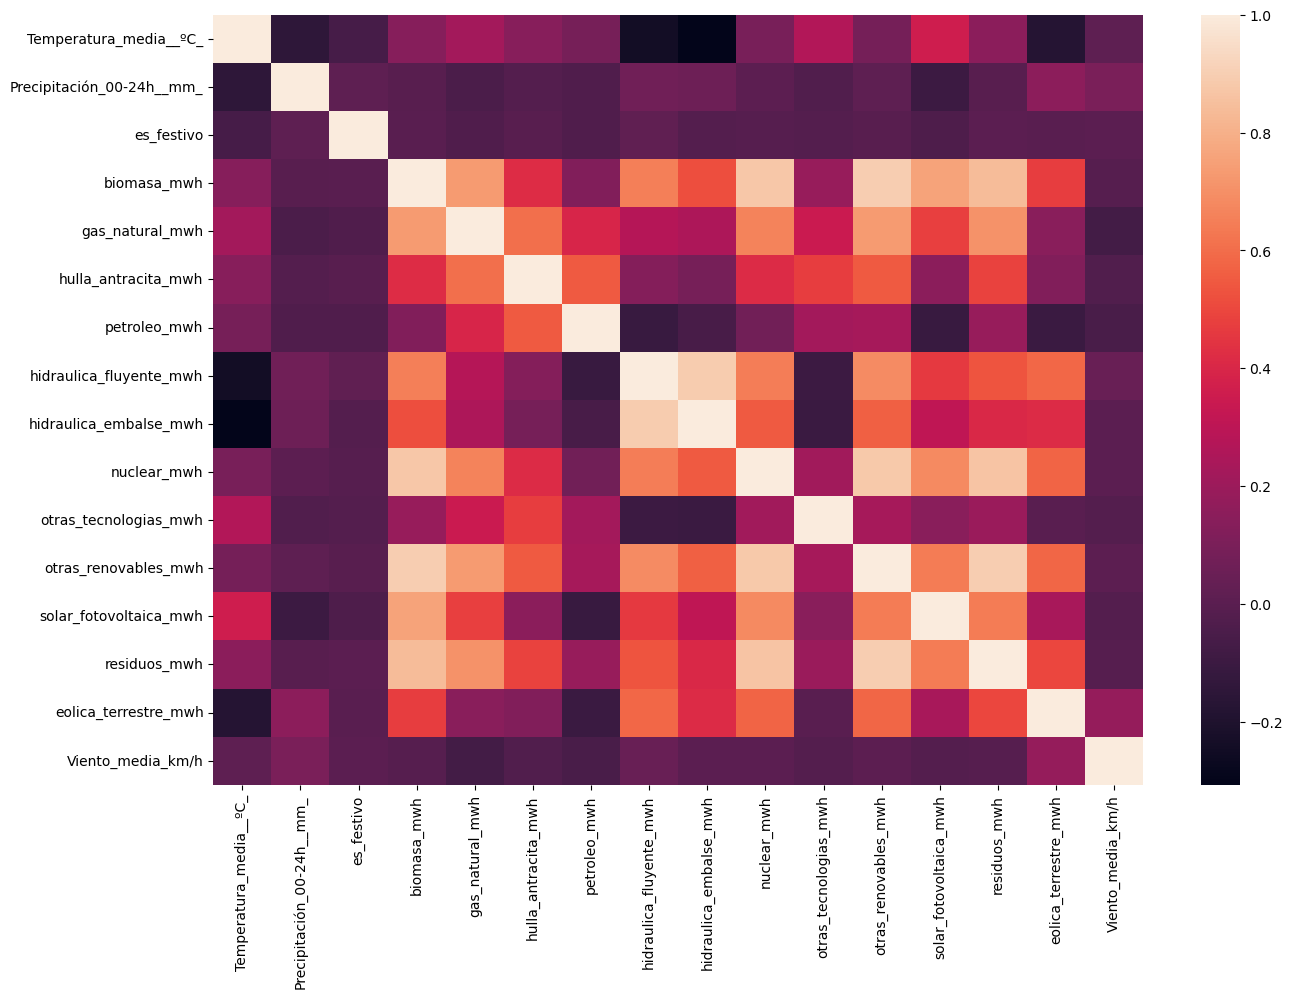

In [ ]:
# =========================================================
# MATRIZ DE CORRELACIÓN TRAS LA LIMPIEZA
# =========================================================

corr_matrix_clean = df_full_copy.corr(numeric_only=True)

plt.figure(figsize=(15, 10))

sns.heatmap(corr_matrix_clean)

plt.show()

Tras el proceso de limpieza y eliminación de variables redundantes, la matriz de correlación presenta una estructura mucho más clara y consistente. Ya no aparecen columnas completamente vacías o con valores faltantes, lo que facilita considerablemente el análisis de relaciones entre variables.

Además, comienzan a observarse ciertos patrones interesantes dentro de los datos. Por ejemplo, la generación de energía solar fotovoltaica tiende a aumentar ligeramente cuando la temperatura media es más elevada, algo razonable debido a la mayor presencia de horas de sol. De forma similar, la generación hidráulica muestra una tendencia inversa, reduciéndose en periodos de temperaturas más altas, normalmente asociados a menores precipitaciones.

---

Aun así, el dataset sigue presentando algunos valores extremos y ciertas anomalías que deben ser tratados antes de utilizar los datos en procesos analíticos o de modelado.

In [ ]:
# =========================================================
# ESTADÍSTICAS DESCRIPTIVAS FORMATEADAS
# =========================================================

# Se limita la visualización a dos decimales para
# evitar notación científica en el describe()

df_full_copy.describe().apply(
    lambda s: s.apply(lambda x: f"{x:.2f}")
)

,Temperatura_media__ºC_,Precipitación_00-24h__mm_,es_festivo,biomasa_mwh,gas_natural_mwh,hulla_antracita_mwh,petroleo_mwh,hidraulica_fluyente_mwh,hidraulica_embalse_mwh,nuclear_mwh,otras_tecnologias_mwh,otras_renovables_mwh,solar_fotovoltaica_mwh,residuos_mwh,eolica_terrestre_mwh,Viento_media_km/h
count,1618374.00,1603006.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00,1690840.00
mean,15.81,1.82,0.03,29016.48,455291.88,28737.48,4288.52,65179.69,168476.91,433547.01,1374.02,5638.11,340027.48,15656.45,476605.19,22.61
std,7.23,6.36,0.18,13900.80,305318.18,27894.57,2763.96,40460.34,127520.83,221250.56,1291.16,2476.07,267727.39,7437.72,364890.34,15.09
min,-16.10,0.00,0.00,492.00,3478.00,0.00,32.00,1070.00,1333.00,680.00,0.00,96.00,10.00,218.00,6342.00,0.00
25%,10.40,0.00,0.00,12334.00,212245.00,10590.00,2576.00,27026.00,65763.00,167392.00,664.00,2530.00,87101.00,7193.00,183180.00,14.50
50%,15.70,0.00,0.00,35028.00,392676.00,23808.00,3707.00,56992.00,126392.00,489232.00,1040.00,6580.00,295336.00,17332.00,379144.00,22.50
75%,21.30,0.20,0.00,40736.00,621192.00,33396.00,5083.00,100596.00,243680.00,658772.00,1411.00,7604.00,549912.00,21820.00,687488.00,31.00
max,40.20,758.00,1.00,54132.00,1630056.00,171352.00,19288.00,159380.00,577304.00,685048.00,5704.00,10944.00,1047012.00,30380.00,1746940.00,199.50


### Análisis de valores atípicos

A partir del análisis estadístico descriptivo del dataset, se identifican varios comportamientos anómalos que conviene tener en cuenta antes de la fase de modelado.

En primer lugar, en la variable de **precipitaciones** se observa una media de aproximadamente `1.82 mm`, mientras que el valor máximo alcanza los `758 mm`. Este tipo de discrepancia puede deberse a eventos meteorológicos extremadamente puntuales (como la DANA de Valencia en 2024) o incluso a posibles errores en la captura de datos. En cualquier caso, al tratarse de valores muy alejados del comportamiento habitual, pueden afectar negativamente a la generalización de los modelos predictivos.

En el caso del **viento medio**, la media se sitúa en torno a `22.6 km/h`, pero se registran valores máximos cercanos a `199.50 km/h`. De nuevo, estos registros pueden corresponder a episodios aislados de alta intensidad, aunque su presencia introduce un sesgo importante en la distribución de la variable.

Respecto a la **generación solar fotovoltaica**, se observa un valor mínimo de `10 MWh`, lo cual resulta inusualmente bajo para el contexto energético español. Este comportamiento podría estar relacionado con errores en la ingesta de datos o inconsistencias en la API de origen.

Por otro lado, tecnologías como **hulla/antracita y otras fuentes fósiles** presentan valores mínimos de `0.0 MWh`. Además, la elevada desviación estándar observada (por ejemplo, en el caso de la hulla/antracita, cercana a `27894.57`) indica una alta variabilidad en el tiempo. Aunque este comportamiento puede reflejar la transición energética hacia fuentes renovables, también introduce valores extremos que pueden dificultar el aprendizaje de los modelos.

---

Es importante señalar que eventos excepcionales como el apagón de 2025 pueden influir en ciertos registros, especialmente en tecnologías con tiempos de respuesta más lentos como la nuclear. Este tipo de situaciones puede generar anomalías temporales en los datos que no siempre quedan correctamente reflejadas en las fuentes originales. Aunque su tratamiento excede el alcance de este trabajo, en un análisis más profundo sería recomendable incorporarlos explícitamente.

### Visualización de Outliers

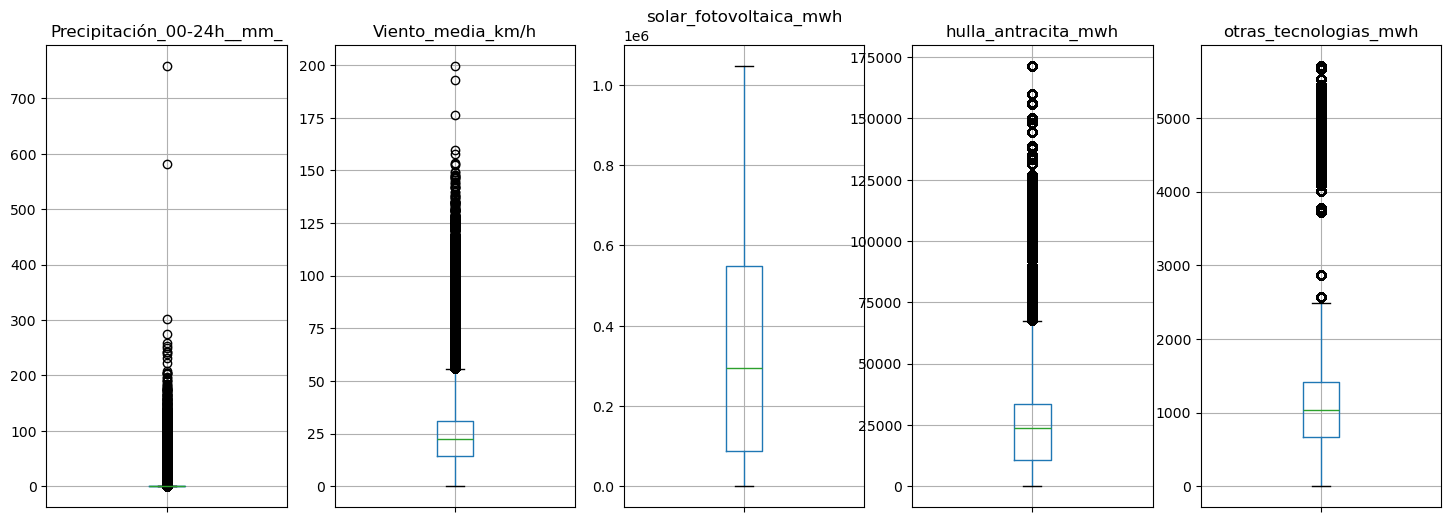

In [ ]:
# =========================================================
# VISUALIZACIÓN DE OUTLIERS MEDIANTE BOXPLOTS
# =========================================================

def create_boxplots(outliers_cols):

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(outliers_cols),
        figsize=(18, 6)
    )

    for i, col in enumerate(outliers_cols):

        df_full_copy.boxplot(
            column=col,
            ax=axes[i]
        )

        axes[i].set_title(col)
        axes[i].set_xticklabels([""])


# Columnas con posible presencia de outliers
outliers_cols = [
    "Precipitación_00-24h__mm_",
    "Viento_media_km/h",
    "solar_fotovoltaica_mwh",
    "hulla_antracita_mwh",
    "otras_tecnologias_mwh"
]

create_boxplots(outliers_cols)

### Tratamiento de valores atípicos

A partir del análisis de los boxplots se identifican distintos comportamientos relevantes en las variables numéricas del dataset, que requieren un tratamiento previo antes del modelado.

En el caso de las **precipitaciones**, se observa una distribución muy asimétrica, propia de un clima relativamente seco pero con episodios puntuales de lluvias intensas. Aunque estos valores pueden ser reales, se decide aplicar un recorte en torno a los `250 mm`, ya que a partir de ese punto la dispersión aumenta de forma significativa y puede afectar al rendimiento del modelo.

Para el **viento medio**, la distribución muestra valores extremos que, aunque menos frecuentes, son coherentes con episodios de fuertes rachas. Sin embargo, dado que los aerogeneradores tienen límites de operación por seguridad, un aumento de viento no siempre se traduce en mayor generación. Por ello, se mantienen los datos dentro de rangos razonables, considerando un umbral cercano a los `100 km/h`.

En la variable de **energía solar fotovoltaica**, no se observan outliers relevantes. La distribución es consistente y refleja el comportamiento estacional esperado, con valores bajos en invierno y picos en periodos de mayor radiación solar. Por este motivo, no se aplica ningún tratamiento específico sobre esta variable.

En cuanto a la **hulla/antracita**, se aprecia una fuerte concentración de valores en niveles bajos y una reducción progresiva de su presencia en el sistema energético. Esto refleja su pérdida de relevancia en el mix energético, por lo que se considera una variable candidata a eliminación.

Finalmente, la categoría de **otras tecnologías** presenta una alta variabilidad y poca interpretabilidad, lo que dificulta su uso en un modelo predictivo. Debido a su baja aportación informativa, también se decide su eliminación junto con otras variables residuales.

---

Dado el tamaño del dataset, se opta por aplicar recortes en lugar de imputaciones, preservando así la mayor cantidad de información real posible sin introducir sesgos artificiales.

Registros pre-tratamiento de outliers: 1690840
Registros post-tratamiento de outliers: 1601759


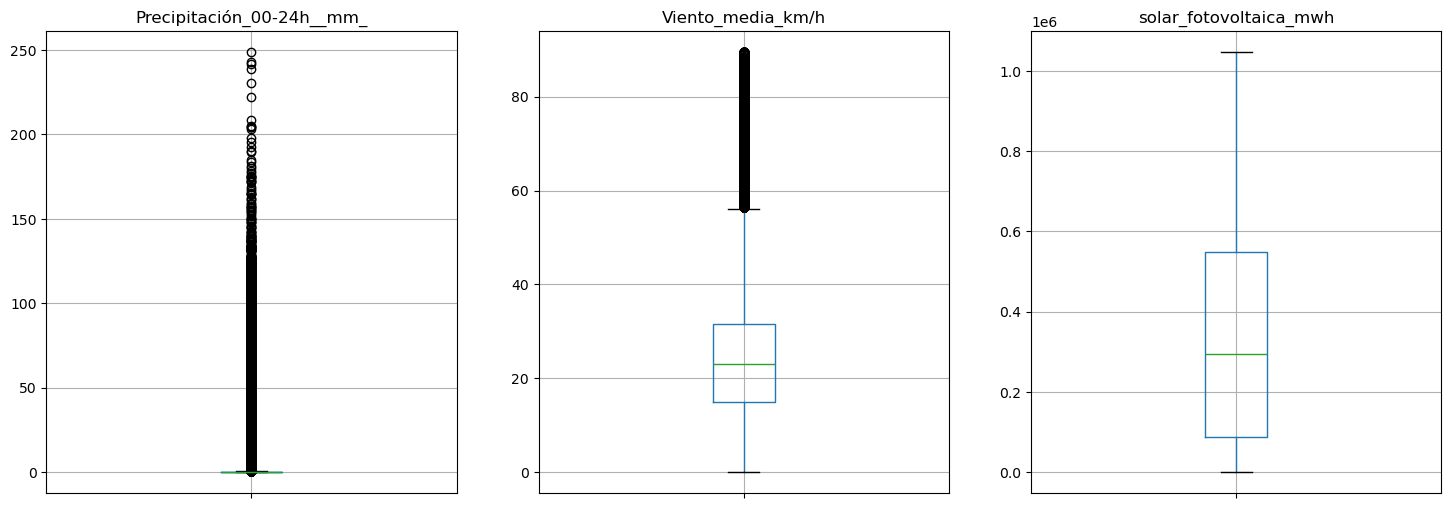

In [ ]:
# =========================================================
# TRATAMIENTO DE OUTLIERS
# =========================================================

print(f"Registros pre-tratamiento de outliers: {df_full_copy.shape[0]}")

# Filtrado de precipitaciones extremas
df_full_copy = df_full_copy[
    df_full_copy["Precipitación_00-24h__mm_"] < 250
]

# Filtrado de valores extremos de viento medio
df_full_copy = df_full_copy[
    df_full_copy["Viento_media_km/h"] < 90
]

# Eliminación de variables energéticas poco informativas
df_full_copy.drop(
    columns=[
        "hulla_antracita_mwh",
        "otras_tecnologias_mwh",
        "otras_renovables_mwh"
    ],
    inplace=True
)

print(f"Registros post-tratamiento de outliers: {df_full_copy.shape[0]}")

# Visualización posterior al tratamiento
outliers_cols = [
    "Precipitación_00-24h__mm_",
    "Viento_media_km/h",
    "solar_fotovoltaica_mwh"
]

create_boxplots(outliers_cols)

Tras el proceso de limpieza, se han eliminado aproximadamente 90.000 registros, lo que representa alrededor de un 5% del total del dataset. Este impacto se considera asumible dado el tamaño global de los datos.

Los nuevos boxplots muestran que, aunque persisten valores extremos, estos reflejan en gran medida la variabilidad real del clima en España, por lo que pueden ser informativos para el modelo en lugar de errores.

En el caso de las precipitaciones, la distribución sigue siendo muy dispersa debido a la diversidad climática del país, con zonas extremadamente secas y otras mucho más húmedas. Esto sugiere que un único modelo nacional puede simplificar en exceso esta variabilidad, siendo más adecuado en el futuro plantear modelos segmentados por regiones climáticas.

Respecto al viento medio, se observa una variabilidad coherente con la geografía española, donde existen zonas con alta exposición al viento frente a otras más protegidas. Los valores extremos no necesariamente representan errores, sino diferencias geográficas reales que pueden aportar información útil al modelo.

### Feature Engineering

Con el objetivo de mejorar la capacidad predictiva del modelo, se generan nuevas variables a partir de la información temporal del dataset. Estas transformaciones permiten que el algoritmo capture patrones estacionales y de comportamiento que no están explícitos en los datos originales.

Dado que los modelos de machine learning no interpretan directamente las fechas, es necesario descomponer esta información en variables más útiles:

- **`mes`**: representa el mes del año. Permite al modelo capturar patrones estacionales, como el aumento del consumo energético en invierno por calefacción o la mayor producción solar en verano debido a las horas de luz.

- **`dia_semana`**: introduce información sobre el día de la semana, facilitando la detección de patrones recurrentes asociados a la actividad laboral e industrial, que suele concentrarse de lunes a viernes.

- **`es_fin_de_semana`**: variable binaria que indica si el día corresponde a fin de semana. Complementa a la variable anterior, permitiendo diferenciar entre periodos de alta y baja actividad económica. Se representa como `1` o `0` para mantener consistencia con otras variables binarias del dataset, como `es_festivo`.

In [ ]:
# =========================================================
# CREACIÓN DE VARIABLES TEMPORALES
# =========================================================

# Asegurar formato datetime y orden temporal
df_full_copy["fecha"] = pd.to_datetime(df_full_copy["fecha"])
df_full_copy = df_full_copy.sort_values("fecha").reset_index(drop=True)

# Extracción de variables temporales
df_full_copy["mes"] = df_full_copy["fecha"].dt.month
df_full_copy["dia_semana"] = df_full_copy["fecha"].dt.dayofweek

# Variable binaria: fin de semana (1 = sí, 0 = no)
df_full_copy["es_fin_de_semana"] = df_full_copy["dia_semana"].isin([5, 6]).astype(int)

# Visualización rápida
df_full_copy.head()

,Estación,Provincia,Temperatura_media__ºC_,Precipitación_00-24h__mm_,archivo_origen,fecha,Provincia_Limpia,ccaa_codigo,es_festivo,biomasa_mwh,...,hidraulica_fluyente_mwh,hidraulica_embalse_mwh,nuclear_mwh,solar_fotovoltaica_mwh,residuos_mwh,eolica_terrestre_mwh,Viento_media_km/h,mes,dia_semana,es_fin_de_semana
0,Estaca de Bares,A Coruña,17.6,0.0,Aemet2020-06-01.xls,2020-06-01,A Coruña,GA,0,6848.0,...,32022.0,74460.0,95104.0,67691.0,5141.0,46137.0,43.0,6,0,0
1,Manilva,Málaga,21.0,0.0,Aemet2020-06-01.xls,2020-06-01,Málaga,AN,0,6848.0,...,32022.0,74460.0,95104.0,67691.0,5141.0,46137.0,18.5,6,0,0
2,Benahavís,Málaga,19.9,0.0,Aemet2020-06-01.xls,2020-06-01,Málaga,AN,0,6848.0,...,32022.0,74460.0,95104.0,67691.0,5141.0,46137.0,15.5,6,0,0
3,"Marbella, Puerto",Málaga,20.2,0.0,Aemet2020-06-01.xls,2020-06-01,Málaga,AN,0,6848.0,...,32022.0,74460.0,95104.0,67691.0,5141.0,46137.0,17.0,6,0,0
4,Marbella,Málaga,NaN,0.0,Aemet2020-06-01.xls,2020-06-01,Málaga,AN,0,6848.0,...,32022.0,74460.0,95104.0,67691.0,5141.0,46137.0,12.5,6,0,0


### Capa Oro

La capa oro representa el nivel final del pipeline de datos, donde se consolidan los datasets preparados para su consumo analítico y su uso en modelos de machine learning.

En esta fase se generan dos versiones del dataset final:

**Dataset sin normalizar**: contiene los datos en su escala original tras el proceso de limpieza y feature engineering. Este conjunto es útil para visualización, análisis exploratorio y generación de gráficas interpretables sin necesidad de aplicar transformaciones adicionales.

**Dataset normalizado**: incluye las variables transformadas y escaladas para adaptarse a los requisitos de los algoritmos de machine learning. Este conjunto está optimizado para el entrenamiento de modelos, ya que reduce problemas de escala y mejora la convergencia.

In [ ]:
# =========================================================
# EXPORTACIÓN DATASET SIN NORMALIZAR (CAPA ORO)
# =========================================================

s3 = connect_s3()

df_clean = df_full_copy.copy()

upload_parquet_to_s3(
    s3,
    bucket=BUCKET_ORO,
    path="generacion-energetica-limpio",
    df=df_clean
)

Conexión establecida.
Subiendo archivo parquet a gcd-pi-oro
Archivo .parquet subido correctamente a s3://gdc-pi-oro/generacion-energetica-limpio.parquet


### Normalización

En esta fase se aplican transformaciones para preparar el dataset de cara al entrenamiento de modelos predictivos.

El sistema eléctrico español se puede entender como una combinación de distintas fuentes de generación con comportamientos diferentes:

- **Generación base (constante)**: fuentes que mantienen una producción estable casi continua.
  - Nuclear: producción estable y prácticamente constante.
  - Biomasa: generación relativamente estable basada en residuos orgánicos.
  - Residuos: incineración de residuos urbanos con comportamiento continuo.

- **Energías renovables (variables objetivo)**: dependen de condiciones ambientales.
  - Solar fotovoltaica: influida por la radiación solar y la meteorología.
  - Eólica: dependiente de la intensidad del viento.
  - Hidráulica fluyente: relacionada con caudal y precipitaciones.

- **Energía gestionable (reserva)**:
  - Hidráulica de embalse: puede regularse según la demanda y disponibilidad de agua.

- **Generación fósil (ajuste de demanda)**:
  - Gas natural y petróleo: se utilizan para cubrir el déficit entre oferta renovable/base y la demanda total.

De forma simplificada, el sistema puede interpretarse como:

`Fósiles = Demanda total - (Base + Renovables + Reserva)`

Las variables objetivo no se normalizan, ya que representan magnitudes físicas que deben mantenerse en su escala original para su interpretación.

A continuación se analizarán las distribuciones mediante histogramas para identificar posibles transformaciones necesarias.

In [ ]:
# =========================================================
# VISUALIZACIÓN DE DISTRIBUCIONES
# =========================================================

def create_distributions(df, cols, num_cols=4):
    
    num_rows = math.ceil(len(cols) / num_cols)
    
    fig, axes = plt.subplots(
        nrows=num_rows,
        ncols=num_cols,
        figsize=(18, 4 * num_rows)
    )
    
    axes = axes.flatten()
    
    for i, col in enumerate(cols):
        sns.histplot(
            data=df,
            x=col,
            kde=True,
            ax=axes[i],
            bins=30
        )
        
        axes[i].set_title(col)

    plt.tight_layout()
    plt.show()

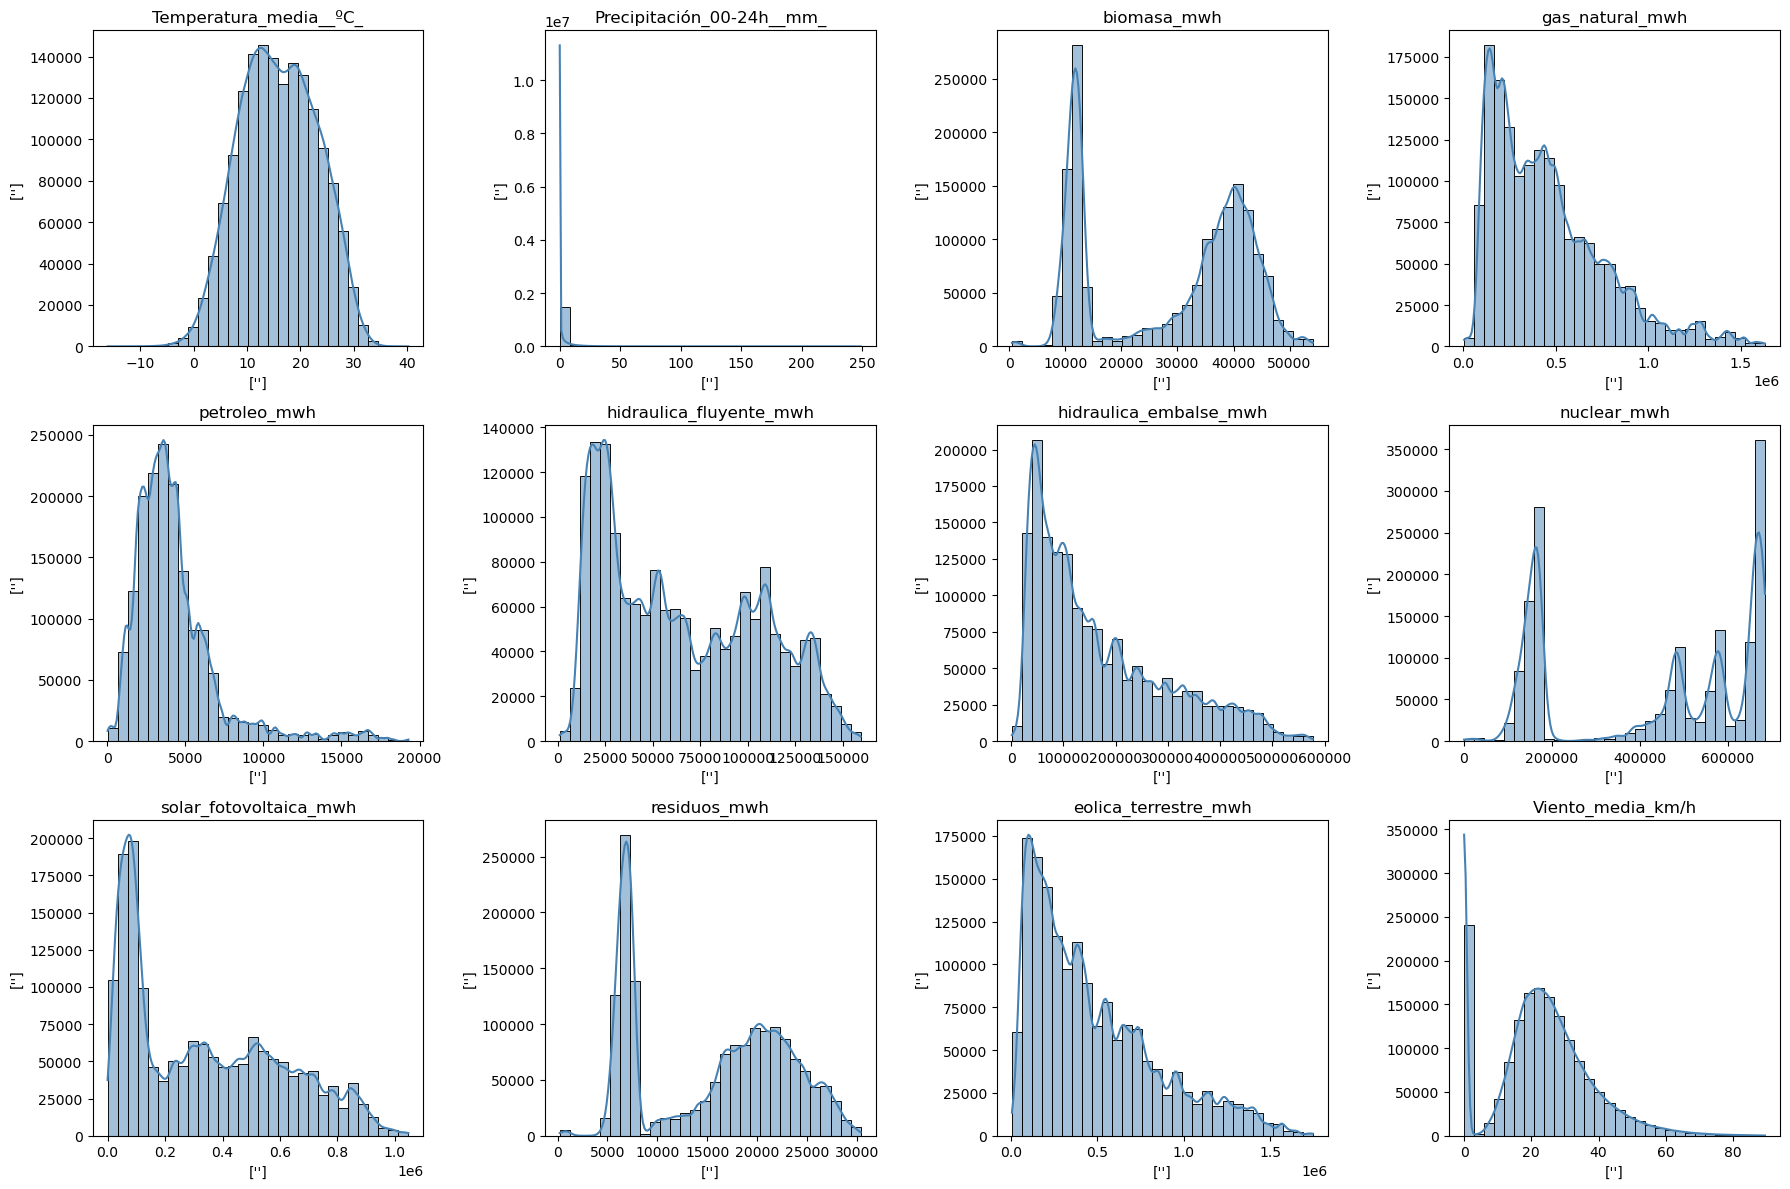

In [ ]:
# =========================================================
# EJECUCIÓN DE DISTRIBUCIONES
# =========================================================

cols = [
    "Temperatura_media__ºC_",
    "Precipitación_00-24h__mm_",
    "biomasa_mwh",
    "gas_natural_mwh",
    "petroleo_mwh",
    "hidraulica_fluyente_mwh",
    "hidraulica_embalse_mwh",
    "nuclear_mwh",
    "solar_fotovoltaica_mwh",
    "residuos_mwh",
    "eolica_terrestre_mwh",
    "Viento_media_km/h"
]

create_distributions(df_clean, cols, num_cols=4)

Las distribuciones de las variables muestran distintos comportamientos que condicionan el tipo de transformación a aplicar:

- **Distribución aproximadamente normal**: como ocurre con la temperatura media, se aplica estandarización mediante *StandardScaler*.

- **Sesgo positivo (cola a la derecha)**: variables como precipitaciones, viento o parte de la generación fósil e hidráulica presentan concentración en valores bajos y colas largas en valores altos. En estos casos se aplica transformación logarítmica.

- **Distribuciones multimodales**: variables como nuclear, biomasa o residuos muestran varios picos asociados a distintos regímenes de producción. Para mantener su estructura relativa se utiliza escalado *Min-Max*.

Las variables objetivo (solar, eólica e hidráulica fluyente) no se normalizan, ya que representan valores físicos en MWh y deben mantenerse en su escala original para la interpretación del modelo.

In [ ]:
# =========================================================
# PIPELINE DE NORMALIZACIÓN
# =========================================================

from sklearn.preprocessing import StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer

# Variables según tipo de distribución
cols_normal = ["Temperatura_media__ºC_"]

cols_skew = [
    "Precipitación_00-24h__mm_",
    "Viento_media_km/h",
    "gas_natural_mwh",
    "petroleo_mwh",
    "hidraulica_embalse_mwh"
]

cols_multimodal = [
    "nuclear_mwh",
    "biomasa_mwh",
    "residuos_mwh"
]

# Transformaciones combinadas
preprocess = ColumnTransformer(
    transformers=[
        ("std", StandardScaler(), cols_normal),
        ("log_transform", FunctionTransformer(np.log1p, validate=True), cols_skew),
        ("minmax", MinMaxScaler(), cols_multimodal)
    ],
    remainder="passthrough"
)

In [ ]:
# =========================================================
# APLICACIÓN DE NORMALIZACIÓN
# =========================================================

target_cols = [
    "solar_fotovoltaica_mwh",
    "eolica_terrestre_mwh",
    "hidraulica_fluyente_mwh"
]

df_clean_norm = df_clean.copy()

# Separación de variables objetivo
df_target = df_clean_norm[target_cols]
df_transform = df_clean_norm.drop(columns=target_cols)

# Ajuste y transformación
norm_data = preprocess.fit_transform(df_transform)

# Recuperación de nombres de columnas tras transformación
cols_output = preprocess.get_feature_names_out()
cols_output_clean = [c.split("__")[-1] for c in cols_output]

# Reconstrucción del DataFrame normalizado
df_norm_data = pd.DataFrame(norm_data, columns=cols_output_clean)

# Reincorporación de variables objetivo
df_norm_clean = pd.concat([df_norm_data, df_target.reset_index(drop=True)], axis=1)

In [ ]:
# =========================================================
# AJUSTE DE NOMBRES DE COLUMNAS TRAS TRANSFORMACIÓN
# =========================================================

df_norm_clean.rename(
    columns={
        "ºC_": "temperatura_media_ºC",
        "mm_": "precipitaciones_medias_diarias_mm"
    },
    inplace=True
)

df_norm_clean.head()

,index,temperatura_media_ºC,precipitaciones_medias_diarias_mm,Viento_media_km/h,gas_natural_mwh,petroleo_mwh,hidraulica_embalse_mwh,nuclear_mwh,biomasa_mwh,residuos_mwh,...,fecha,Provincia_Limpia,ccaa_codigo,es_festivo,mes,dia_semana,es_fin_de_semana,solar_fotovoltaica_mwh,eolica_terrestre_mwh,hidraulica_fluyente_mwh
0,0,0.236426,0.0,3.78419,12.160317,8.796339,11.218031,0.137973,0.118494,0.163219,...,2020-06-01,A Coruña,GA,0,6,0,0,67691.0,46137.0,32022.0
1,1,0.711003,0.0,2.970414,12.160317,8.796339,11.218031,0.137973,0.118494,0.163219,...,2020-06-01,Málaga,AN,0,6,0,0,67691.0,46137.0,32022.0
2,2,0.557464,0.0,2.80336,12.160317,8.796339,11.218031,0.137973,0.118494,0.163219,...,2020-06-01,Málaga,AN,0,6,0,0,67691.0,46137.0,32022.0
3,3,0.599338,0.0,2.890372,12.160317,8.796339,11.218031,0.137973,0.118494,0.163219,...,2020-06-01,Málaga,AN,0,6,0,0,67691.0,46137.0,32022.0
4,4,NaN,0.0,2.60269,12.160317,8.796339,11.218031,0.137973,0.118494,0.163219,...,2020-06-01,Málaga,AN,0,6,0,0,67691.0,46137.0,32022.0


In [ ]:
# =========================================================
# EXPORTACIÓN DATASET NORMALIZADO (CAPA ORO)
# =========================================================

s3 = connect_s3()

upload_parquet_to_s3(
    s3,
    bucket=BUCKET_ORO,
    path="generacion-energetica-normalizado",
    df=df_norm_clean
)

Conexión establecida.
Subiendo archivo parquet a gcd-pi-oro
Archivo .parquet subido correctamente a s3://gdc-pi-oro/generacion-energetica-normalizado.parquet


## Fase 4: Despliegue y visualización

En esta etapa se desarrolla una pequeña capa de visualización para explorar los datos ya procesados. El objetivo es construir un dashboard sencillo que permita analizar patrones relevantes del consumo y la generación energética.

Se utilizará el dataset limpio sin normalizar generado en fases anteriores, ya que mantiene los valores originales y facilita la interpretación de las métricas.

In [ ]:
# =========================================================
# CARGA DEL DATASET LIMPIO DESDE S3 (CAPA ORO)
# =========================================================

df_clean_path = "s3://gdc-pi-oro/generacion-energetica-limpio.parquet"

df_clean = wr.s3.read_parquet(path=df_clean_path)

df_clean_copy = df_clean.copy()

In [ ]:
# =========================================================
# VISUALIZACIÓN MIX ENERGÉTICO (2025)
# =========================================================

alt.data_transformers.disable_max_rows()

# Filtrado del año de análisis
df_year = df_clean_copy[
    df_clean_copy["fecha"].between("2025-01-01", "2025-12-31")
]

# Tecnologías energéticas a analizar
techs = [
    "biomasa_mwh",
    "gas_natural_mwh",
    "petroleo_mwh",
    "hidraulica_fluyente_mwh",
    "hidraulica_embalse_mwh",
    "nuclear_mwh",
    "solar_fotovoltaica_mwh",
    "residuos_mwh",
    "eolica_terrestre_mwh"
]

# Agregación diaria para reducir ruido
df_grouped_year = df_year.groupby("fecha")[techs].mean().reset_index()

# Formato largo para Altair
df_temp = df_grouped_year.melt(
    id_vars=["fecha"],
    value_vars=techs,
    var_name="Tecnologia",
    value_name="MWh"
)

# Limpieza de etiquetas
df_temp["Tecnologia"] = (
    df_temp["Tecnologia"]
    .str.replace("_mwh", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

# Gráfico de área apilada
energy_mix = (
    alt.Chart(df_temp)
    .mark_area(opacity=0.8)
    .encode(
        x=alt.X("fecha:T", title="Fecha"),
        y=alt.Y("MWh:Q", title="Generación eléctrica (MWh)", stack="zero"),
        color=alt.Color("Tecnologia:N", title="Tecnología"),
        tooltip=["fecha:T", "Tecnologia:N", "MWh:Q"]
    )
    .properties(
        title="Mix de generación eléctrica en España (2025)",
        width=1000,
        height=450
    )
    .interactive()
)

energy_mix

alt.Chart(...)

In [ ]:
# =========================================================
# RELACIÓN VIENTO - EÓLICA Y TEMPERATURA - SOLAR (2025)
# =========================================================

# Relación viento vs eólica
df_grouped = (
    df_year
    .groupby("fecha")
    .agg({
        "Viento_media_km/h": "mean",
        "eolica_terrestre_mwh": "mean"
    })
    .reset_index()
)

df_grouped["mes"] = df_grouped["fecha"].dt.month

wind_aerogenerator_energy = (
    alt.Chart(df_grouped)
    .mark_point()
    .encode(
        x=alt.X("Viento_media_km/h:Q", title="Viento medio (km/h)"),
        y=alt.Y("eolica_terrestre_mwh:Q", title="Eólica terrestre (MWh)"),
        color=alt.Color("mes:O", title="Mes", scale=alt.Scale(scheme="category20")),
        tooltip=[
            alt.Tooltip("fecha:T", title="Fecha"),
            alt.Tooltip("Viento_media_km/h:Q", title="Viento medio (km/h)"),
            alt.Tooltip("eolica_terrestre_mwh:Q", title="Eólica (MWh)")
        ]
    )
    .properties(
        title="Relación entre viento y generación eólica (2025)",
        width=500,
        height=500
    )
)

# Relación temperatura vs solar
df_grouped_2 = (
    df_year
    .groupby("fecha")
    .agg({
        "Temperatura_media__ºC_": "mean",
        "solar_fotovoltaica_mwh": "mean"
    })
    .reset_index()
)

df_grouped_2["mes"] = df_grouped_2["fecha"].dt.month

temp_solar_energy = (
    alt.Chart(df_grouped_2)
    .mark_point()
    .encode(
        x=alt.X("Temperatura_media__ºC_:Q", title="Temperatura media (ºC)"),
        y=alt.Y("solar_fotovoltaica_mwh:Q", title="Solar fotovoltaica (MWh)"),
        color=alt.Color("mes:O", title="Mes", scale=alt.Scale(scheme="category20")),
        tooltip=[
            alt.Tooltip("fecha:T", title="Fecha"),
            alt.Tooltip("Temperatura_media__ºC_:Q", title="Temperatura media (ºC)"),
            alt.Tooltip("solar_fotovoltaica_mwh:Q", title="Solar (MWh)")
        ]
    )
    .properties(
        title="Relación entre temperatura y generación solar (2025)",
        width=500,
        height=500
    )
)

wind_aerogenerator_energy | temp_solar_energy

alt.HConcatChart(...)

In [ ]:
# =========================================================
# GRÁFICO DONUT: MIX ENERGÉTICO TOTAL (2025)
# =========================================================

# Cálculo de totales
total = df_year.sum(numeric_only=True)

total_clean_energy = total[
    ["solar_fotovoltaica_mwh", "eolica_terrestre_mwh", "hidraulica_fluyente_mwh", "hidraulica_embalse_mwh"]
].sum()

total_fossiles = total[["gas_natural_mwh", "petroleo_mwh"]].sum()

total_base = total[["nuclear_mwh", "biomasa_mwh", "residuos_mwh"]].sum()

# Dataset agregado por categorías
df_donut = pd.DataFrame({
    "Categoria": [
        "Renovables",
        "Base (Nuclear / Térmica)",
        "Fósiles (Gas / Petróleo)"
    ],
    "MWh": [
        total_clean_energy,
        total_base,
        total_fossiles
    ]
})

# Porcentajes
df_donut["porcentaje"] = (df_donut["MWh"] / df_donut["MWh"].sum()) * 100

# Paleta de colores
colors = alt.Scale(
    domain=["Renovables", "Base (Nuclear / Térmica)", "Fósiles (Gas / Petróleo)"],
    range=["#2ca02c", "#ff7f0e", "#7f7f7f"]
)

# Gráfico donut
donut = (
    alt.Chart(df_donut)
    .mark_arc(innerRadius=90, stroke="white", strokeWidth=2)
    .encode(
        theta=alt.Theta(field="MWh", type="quantitative"),
        color=alt.Color("Categoria:N", scale=colors, title="Tipo de energía"),
        tooltip=[
            alt.Tooltip("Categoria:N", title="Categoría"),
            alt.Tooltip("MWh:Q", title="Producción total (MWh)"),
            alt.Tooltip("porcentaje:Q", title="Porcentaje (%)")
        ]
    )
    .properties(
        title="Distribución de generación energética (2025)",
        width=400,
        height=400
    )
)

donut

alt.Chart(...)

## Fase 5: Dashboard de Datos

In [ ]:
# =========================================================
# DASHBOARD FINAL (2025)
# =========================================================

alt.data_transformers.disable_max_rows()

dashboard_final = (
    energy_mix
    & (wind_aerogenerator_energy | temp_solar_energy)
    & donut
).resolve_scale(
    color="independent"
)

dashboard_final = dashboard_final.properties(
    title=alt.TitleParams(
        text="Dashboard: Datos Energéticos Nacionales (2025)",
        fontSize=22,
        anchor="middle",
        offset=20
    )
)

dashboard_final

alt.VConcatChart(...)